In [2]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-5-nano")

In [8]:
# create a state of subgraph

class LLMQASUB(TypedDict):

    joke_en : str
    joke_hi : str

In [11]:
# define function of subgraph

def translate_joke(state : LLMQASUB) -> LLMQASUB:

    joke_eng = state['joke_en']
    prompt = f"just translate the joke in hindi language do not additional work and give only hindi version of joke in return : {joke_eng} "

    joke_hin = llm.invoke(prompt)

    parser = StrOutputParser()
    clean_string = parser.invoke(joke_hin)

    return {"joke_hi" : clean_string}

In [12]:
# define your graph
subgraph = StateGraph(LLMQASUB)

# add nodes to your graph
subgraph.add_node("translate_joke",translate_joke)

# add edges to your graph
subgraph.add_edge(START,"translate_joke")
subgraph.add_edge("translate_joke",END)

# compile the graph
workflowsub = subgraph.compile()


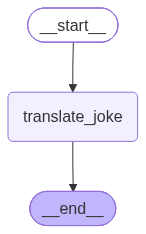

In [13]:
workflowsub

In [16]:
# create a state

class LLMQA(TypedDict):

    topic : str
    joke_english : str
    joke_hindi : str

In [18]:
# define function

def llm_joke(state : LLMQA) -> LLMQA:

    que = state['topic']
    prompt = f"give a one liner joke on this topic : {que}"

    ans = llm.invoke(prompt)

    parser = StrOutputParser()
    clean_string = parser.invoke(ans)
    state["joke_english"] = clean_string

    return state

In [19]:
def translation(state : LLMQA) -> LLMQA:

    en_joke = state['joke_english']

    result = workflowsub.invoke({"joke_en" : en_joke})

    return {"joke_hindi":result["joke_hi"]}

In [20]:
# define your graph
graph = StateGraph(LLMQA)

# add nodes to your graph
graph.add_node("llm_joke",llm_joke)
graph.add_node("translation",translation)

# add edges to your graph
graph.add_edge(START,"llm_joke")
graph.add_edge("llm_joke","translation")
graph.add_edge("translation",END)

# compile the graph
workflow = graph.compile()


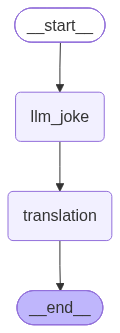

In [21]:
workflow

In [22]:
# execute the graph
query = input("Enter the topic :: ")
initial_state = {"topic" : query}

final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'apple', 'joke_english': 'Why did the apple stop in the middle of the road? It ran out of juice.', 'joke_hindi': 'सड़क के बीच में सेब क्यों रुक गया? उसके पास रस खत्म हो गया था।'}
